# [LAB-06] 3. KDE Plot

## #01. 준비작업

### 1. 패키지 가져오기

In [1]:
from jussam import load_data
from helpers import *
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


## #02. 일변량 커널 밀도

### 1. 단일 분포 --> 하나의 변수에 대한 KDE Plot

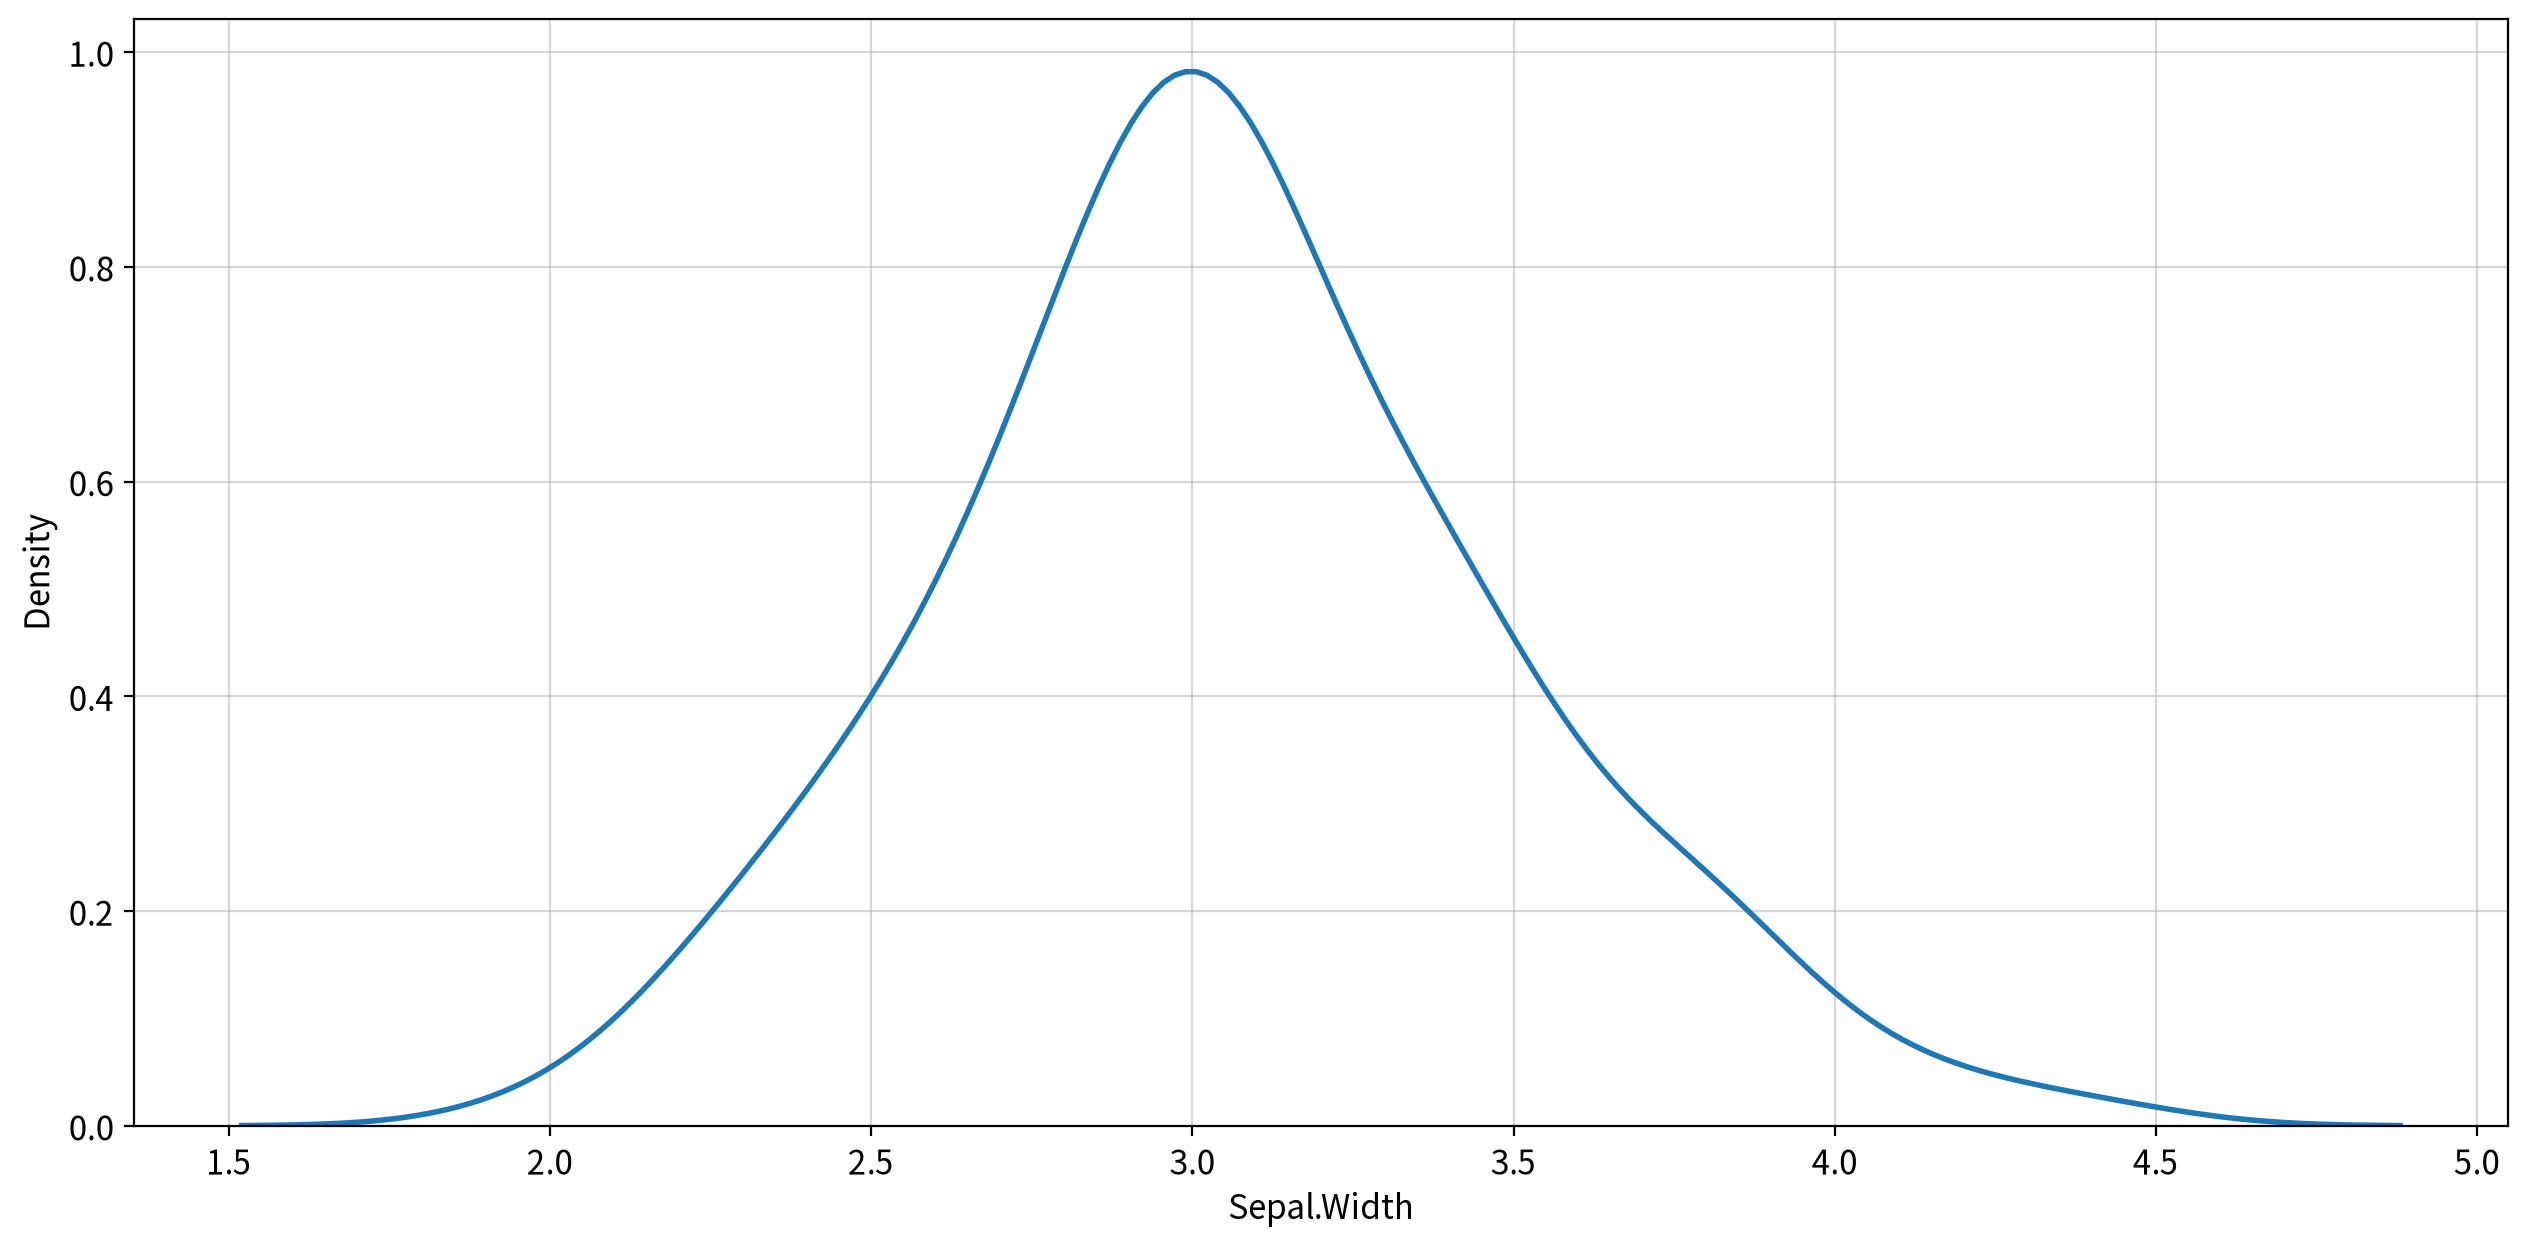

In [3]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기 (아래 패턴 3가지는 모두 결과가 동일함)
# [패턴1] 자동인식 패턴
# sb.kdeplot(data=origin["Sepal.Width"])
# [패턴2] 개별 데이터 지정 패턴
# sb.kdeplot(x=origin["Sepal.Width"])
# [패턴3] DataFrame 지정 패턴
sb.kdeplot(data=origin, x="Sepal.Width", linewidth=2)

# 출력
my_plot.show()

### 2. 다중 분포

- 데이터프레임을 data 파라미터에 적용하면서 x나 y파라미터를 지정하지 않으면 모든 연속형 변수에 대한 커널 밀도 곡선이 표현된다.

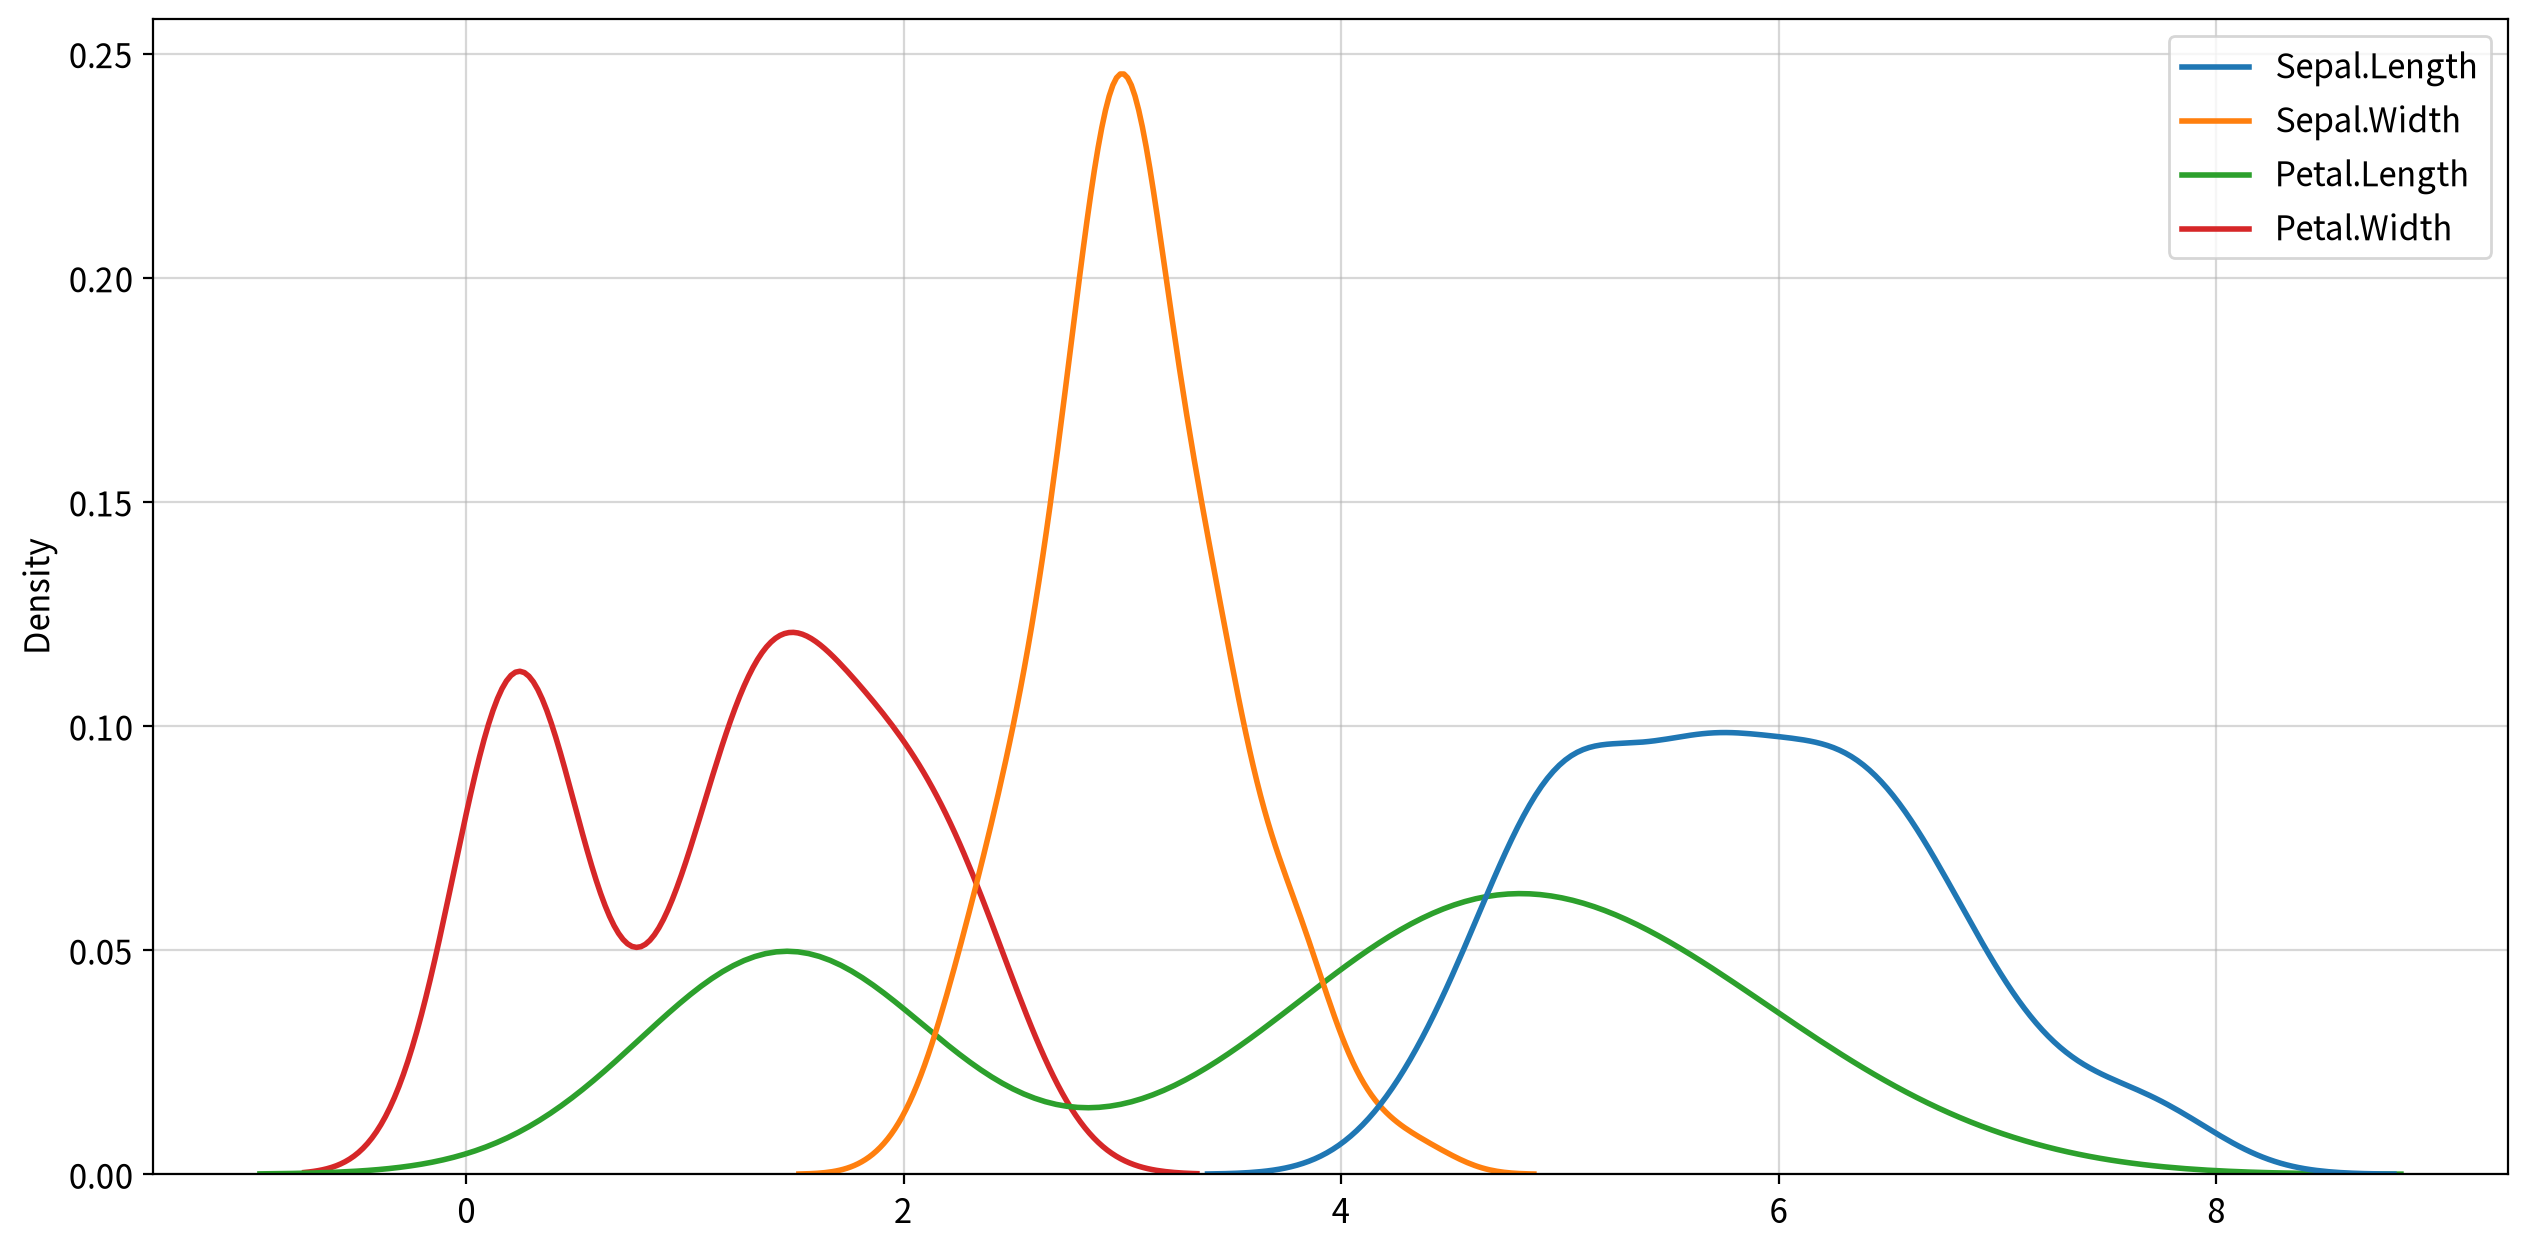

In [4]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기 - x 대신 y를 설정할 경우 가로로 표시된다.
sb.kdeplot(data=origin)

# 출력
my_plot.show()

### 3. 옵션 설정

- **hue** : 명목형 변수를 지정하여 범주에 따라 그래프를 색상별로 분기한다.
- **fill=True** : 밀도 곡선의 내부 면적을 색상으로 채워 시각적 무게감을 부여한다.
- `alpha` : `0~1`사이의 값으로 면의 투명도를 조절한다. 
    - `0=투명`, `1=불투명`
- `palette` : 데이터 특성에 맞는 색상 팔레트를 지정한다.
  - ex: pastel, Blues 등

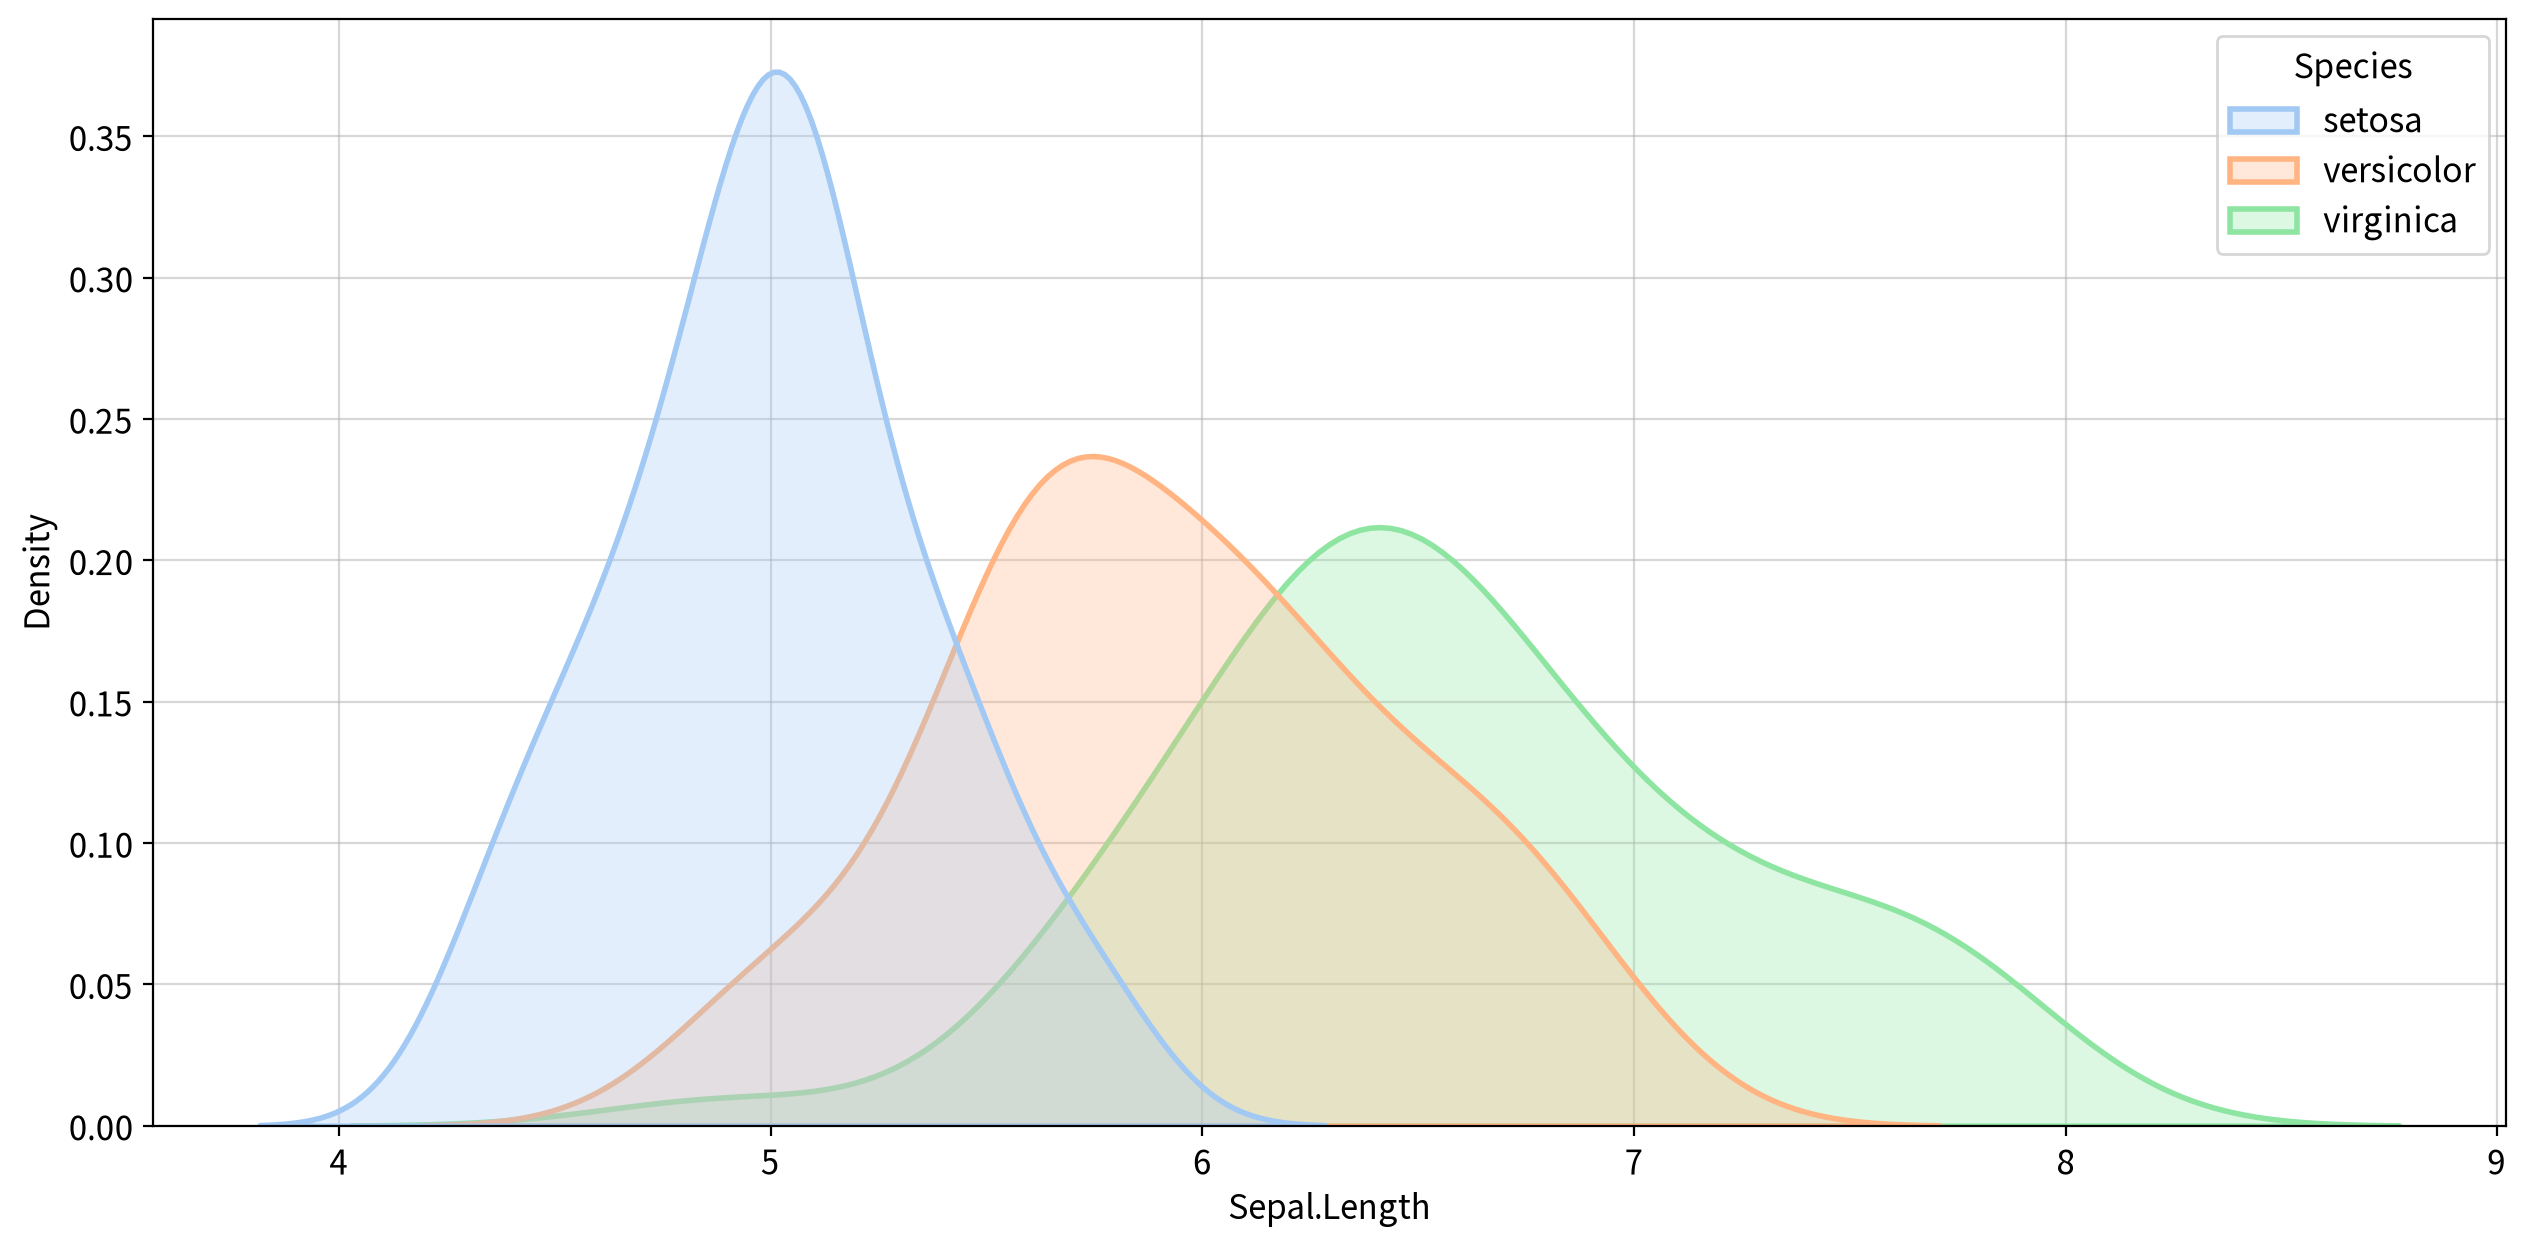

In [5]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기
sb.kdeplot(
    data=origin,        # 데이터 연결
    x="Sepal.Length",   # 분포를 확인할 컬럼 지정
    hue="Species",      # 범주 지정
    fill=True,          # 면 색상 채움
    alpha=0.3,          # 면 색상의 투명도
    palette="pastel",   # 색상 팔레트
    linewidth=2         # 선의 두께
)

# 출력
my_plot.show()

## #03. 이변량 커널밀도

### 1. x에 따른 y분포

- x 파라미터와 y파라미터를 모두 설정한다.

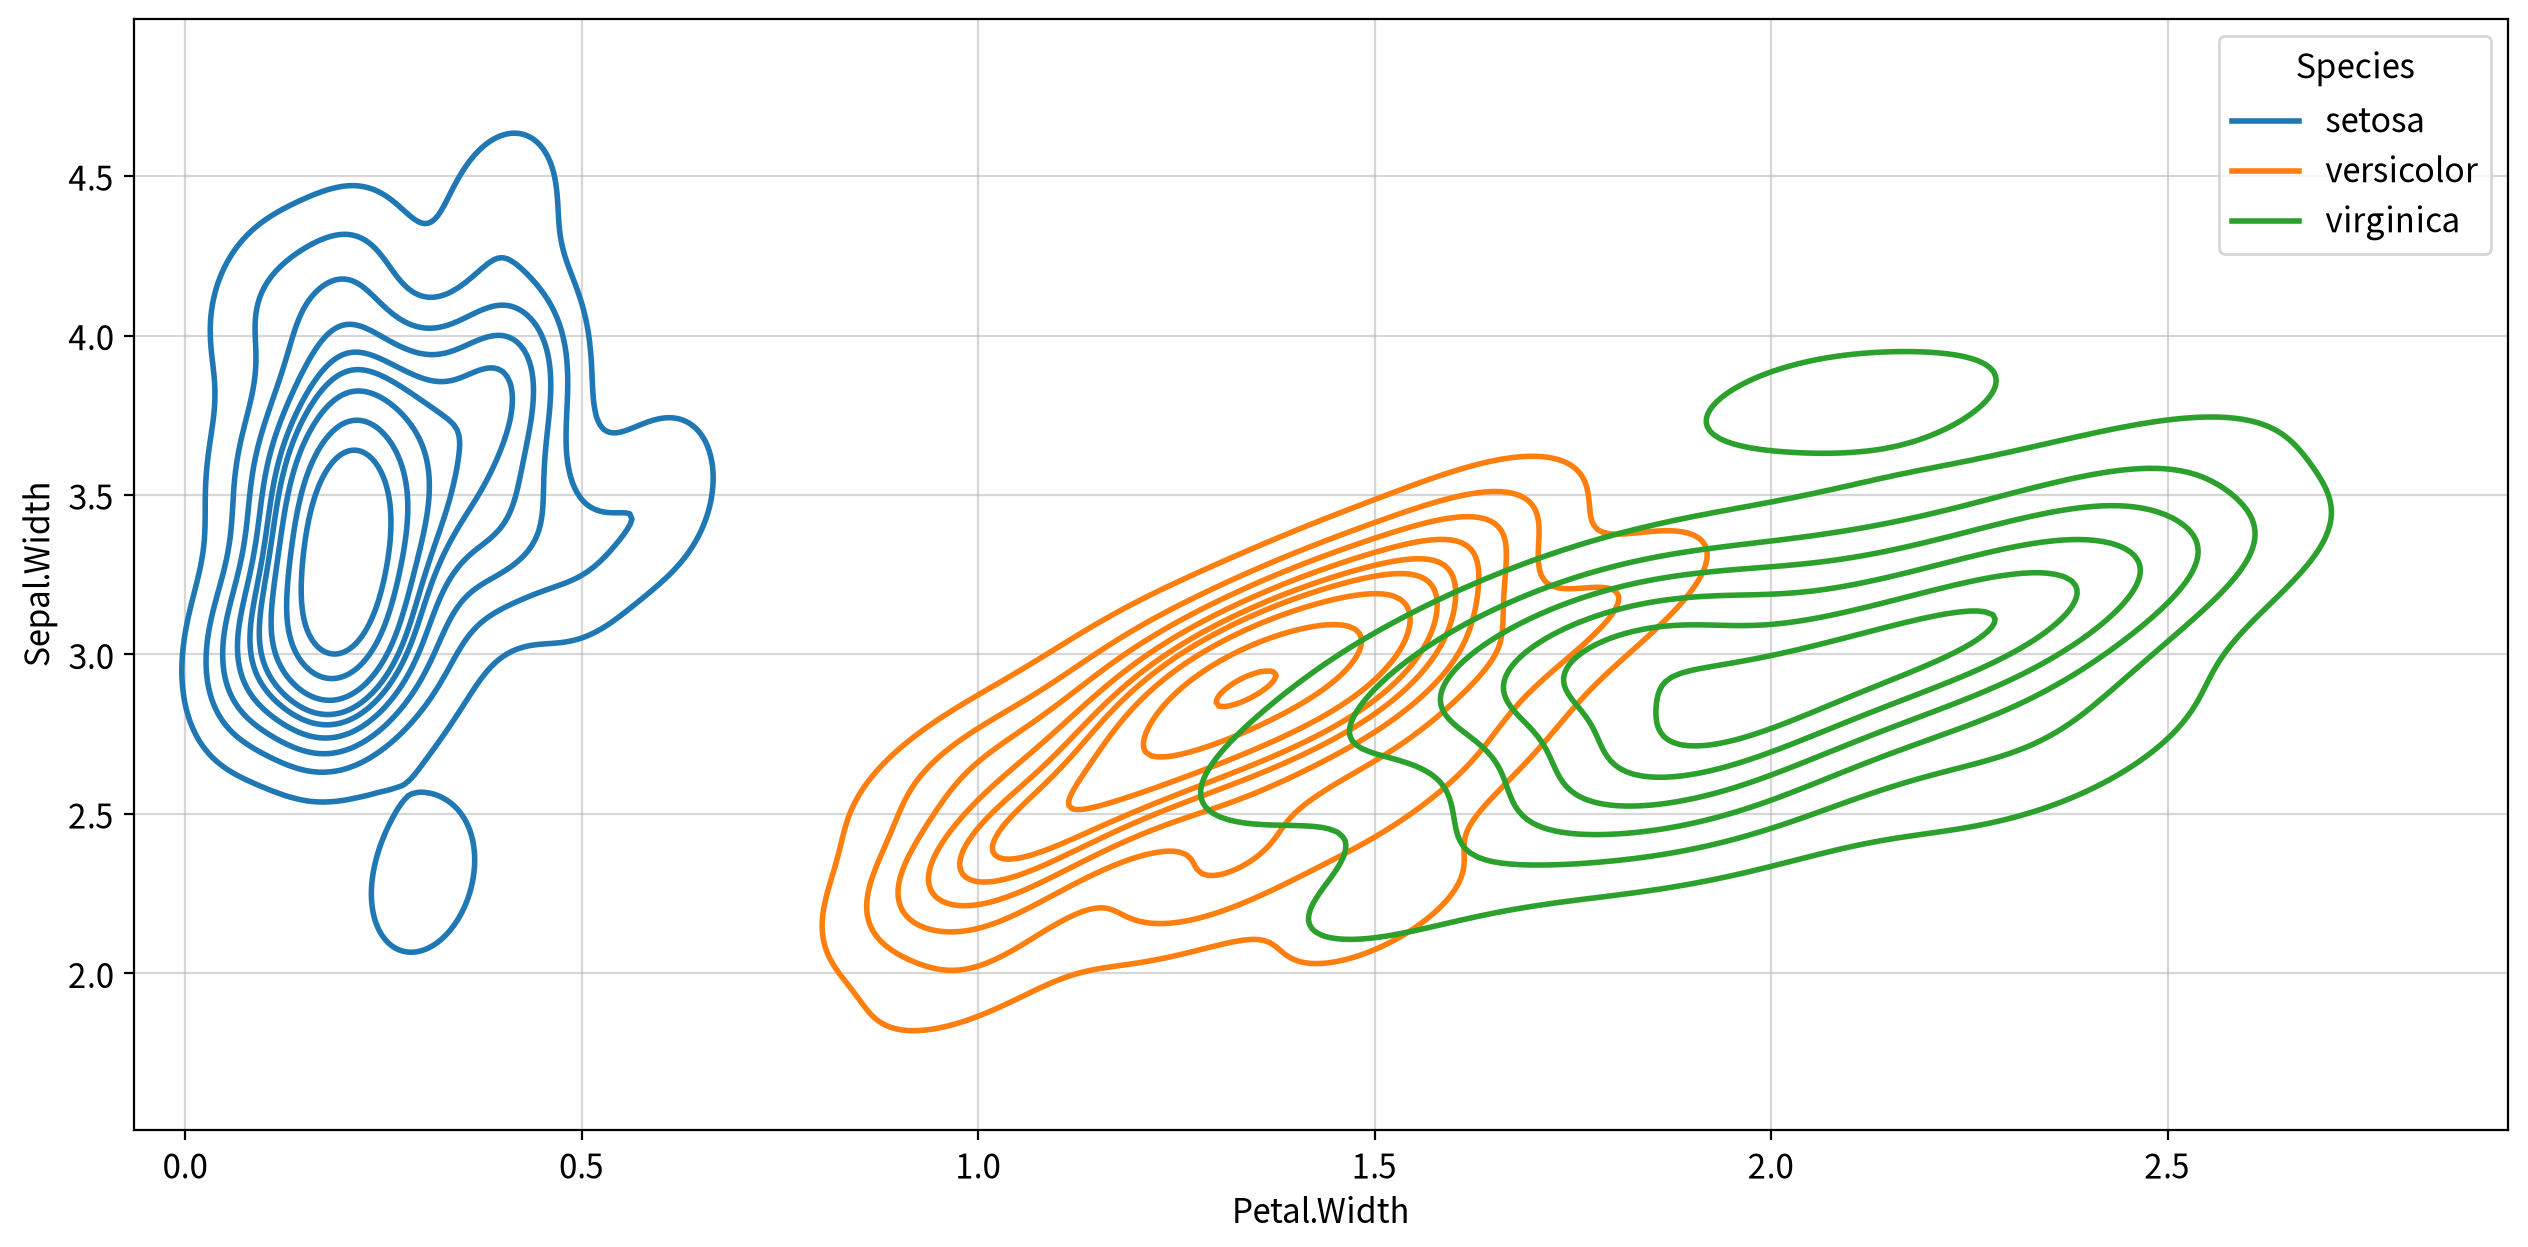

In [6]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기
sb.kdeplot(data=origin, x="Petal.Width", 
           y="Sepal.Width", hue="Species")

# 출력
my_plot.show()

#### 💡 인사이트

- Petal.Width 기준으로 setosa는 완전히 분리되며, versicolor와 virginica는 부분적으로 겹침

- 🔵 **setosa(파란색): 가장 좁은 꽃잎 폭(0~0.6) & 중간 정도의 꽃받침 폭(2.0~4.6)**
  - 가장 왼쪽에 집중된 분포로 다른 종과 명확하게 분리됨
- 🟠 **versicolor(주황색): 중간 크기의 꽃잎 폭(1.0~2.0) & 가장 좁은 꽃받침 폭(~3.5)**
  - setosa와 virginica 사이의 중간 특성을 보유
  - 두 종 사이에 겹치는 영역이 존재
- 🟢 **virginica(초록색): 가장 넓은 꽃잎 폭(2.0~2.5) & 중간~넓은 꽃받침 폭(2.5~4.0)**
  - 오른쪽 상단에 위치하여 다른 종과 구분됨

## #04. 커널밀도와 평균값을 함께 표시하기

### 1. 평균값 구하기

In [7]:
mean_sepal_width = origin["Sepal.Width"].mean()
print(mean_sepal_width)

3.0573333333333337


### 2. 커널밀도 + 평균값

- **ax.axvline()** : x축 지점에 수직인 세로 직선을 그릴 수 있다.
- **ax.text()** : 특정 좌표 지점에 텍스트를 표시할 수 있다.

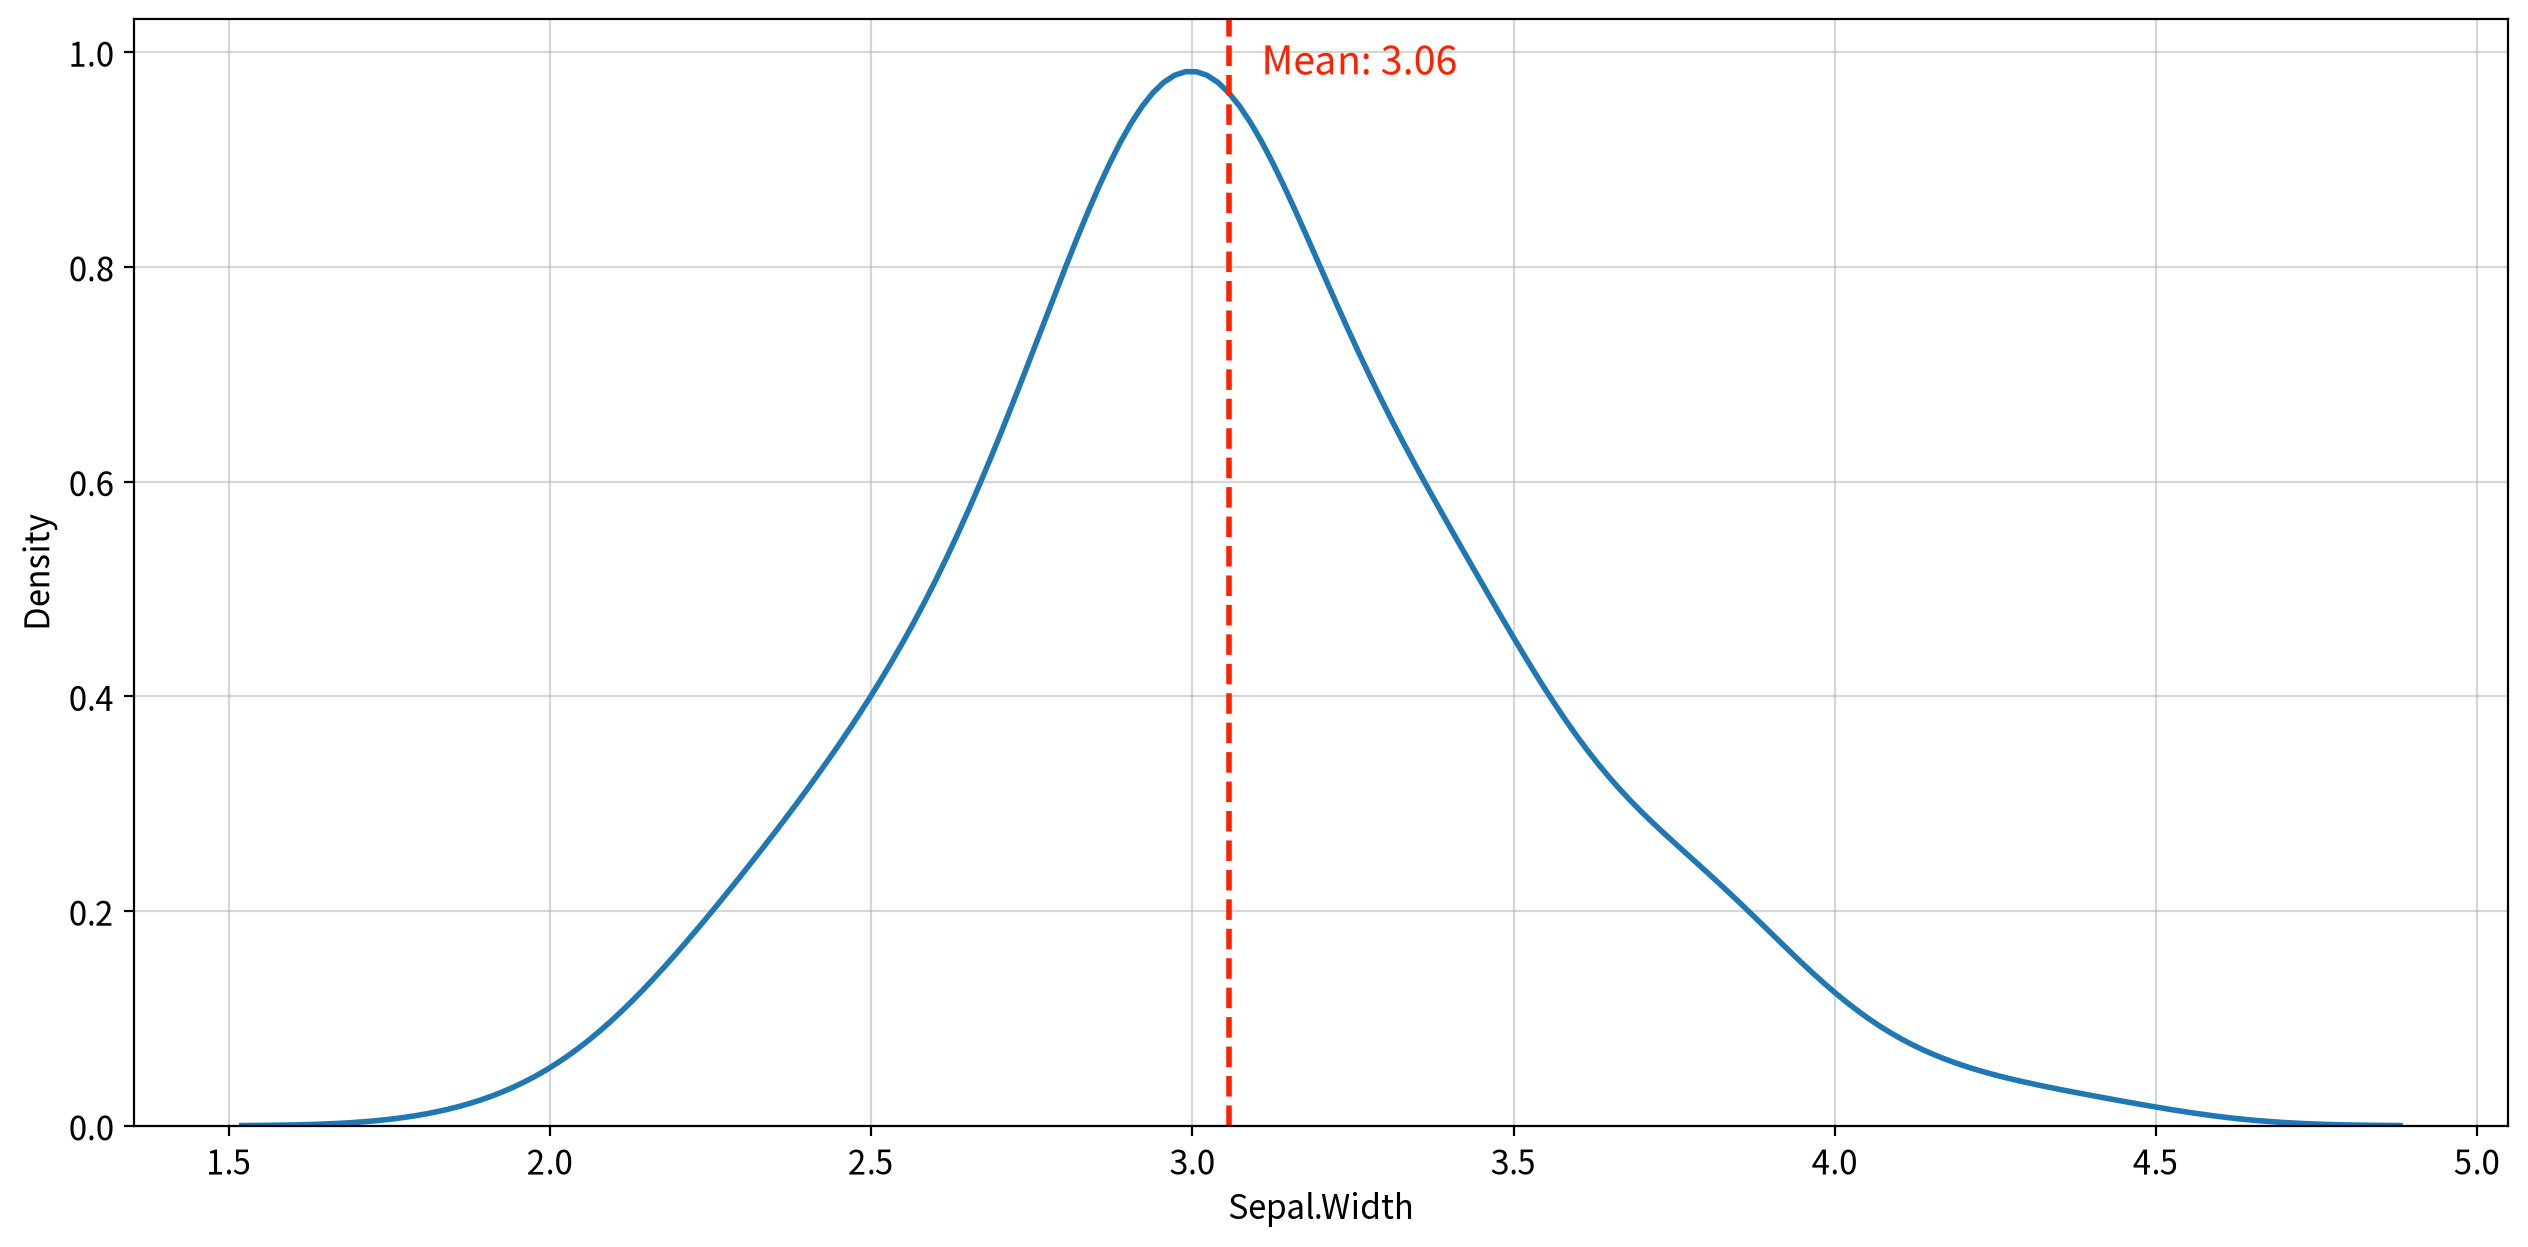

In [8]:
# 그래프 초기화
fig, ax = my_plot.init()

# 그래프 그리기
sb.kdeplot(data=origin, x="Sepal.Width")

# 평균에 대한 수직선 추가
ax.axvline(x=mean_sepal_width, linestyle='--', color='#ff2200')

# 텍스트 표시하기
ax.text(x=mean_sepal_width + 0.05, y=ax.get_ylim()[1] * 0.95, 
        s=f'Mean: {mean_sepal_width:.2f}', color='#ff2200', fontsize=14)

# 출력
my_plot.show()

#### 💡 인사이트

- 📊 **Sepal.Width의 분포는 대칭적인 종 모양의 단봉형 분포를 나타냄**

- 📍 **평균값(Mean: 3.06)이 분포의 최고점과 일치함**
  - 중앙에 위치한 수직선이 커널밀도 곡선의 피크와 겹침
  - 데이터가 평균을 중심으로 균형잡혀 분포함을 의미
- 📈 **분포의 범위는 약 1.5~5.0 사이에 집중**
  - 2.0~4.0 구간에 가장 높은 밀도로 관찰됨
  - 양쪽 끝으로 갈수록 밀도가 점진적으로 감소
- 🔔 **정규분포(Normal Distribution)에 가까운 형태**
  - 대칭성이 뚜렷하고 이상치(Outlier)가 거의 없음을 시사
- 🎯 **평균 3.06을 중심으로 ±0.5 범위(약 2.5~3.5)에 대부분의 데이터가 집중**

## #05. 모듈화 기능 확인

### 1. 단순 사용 방법

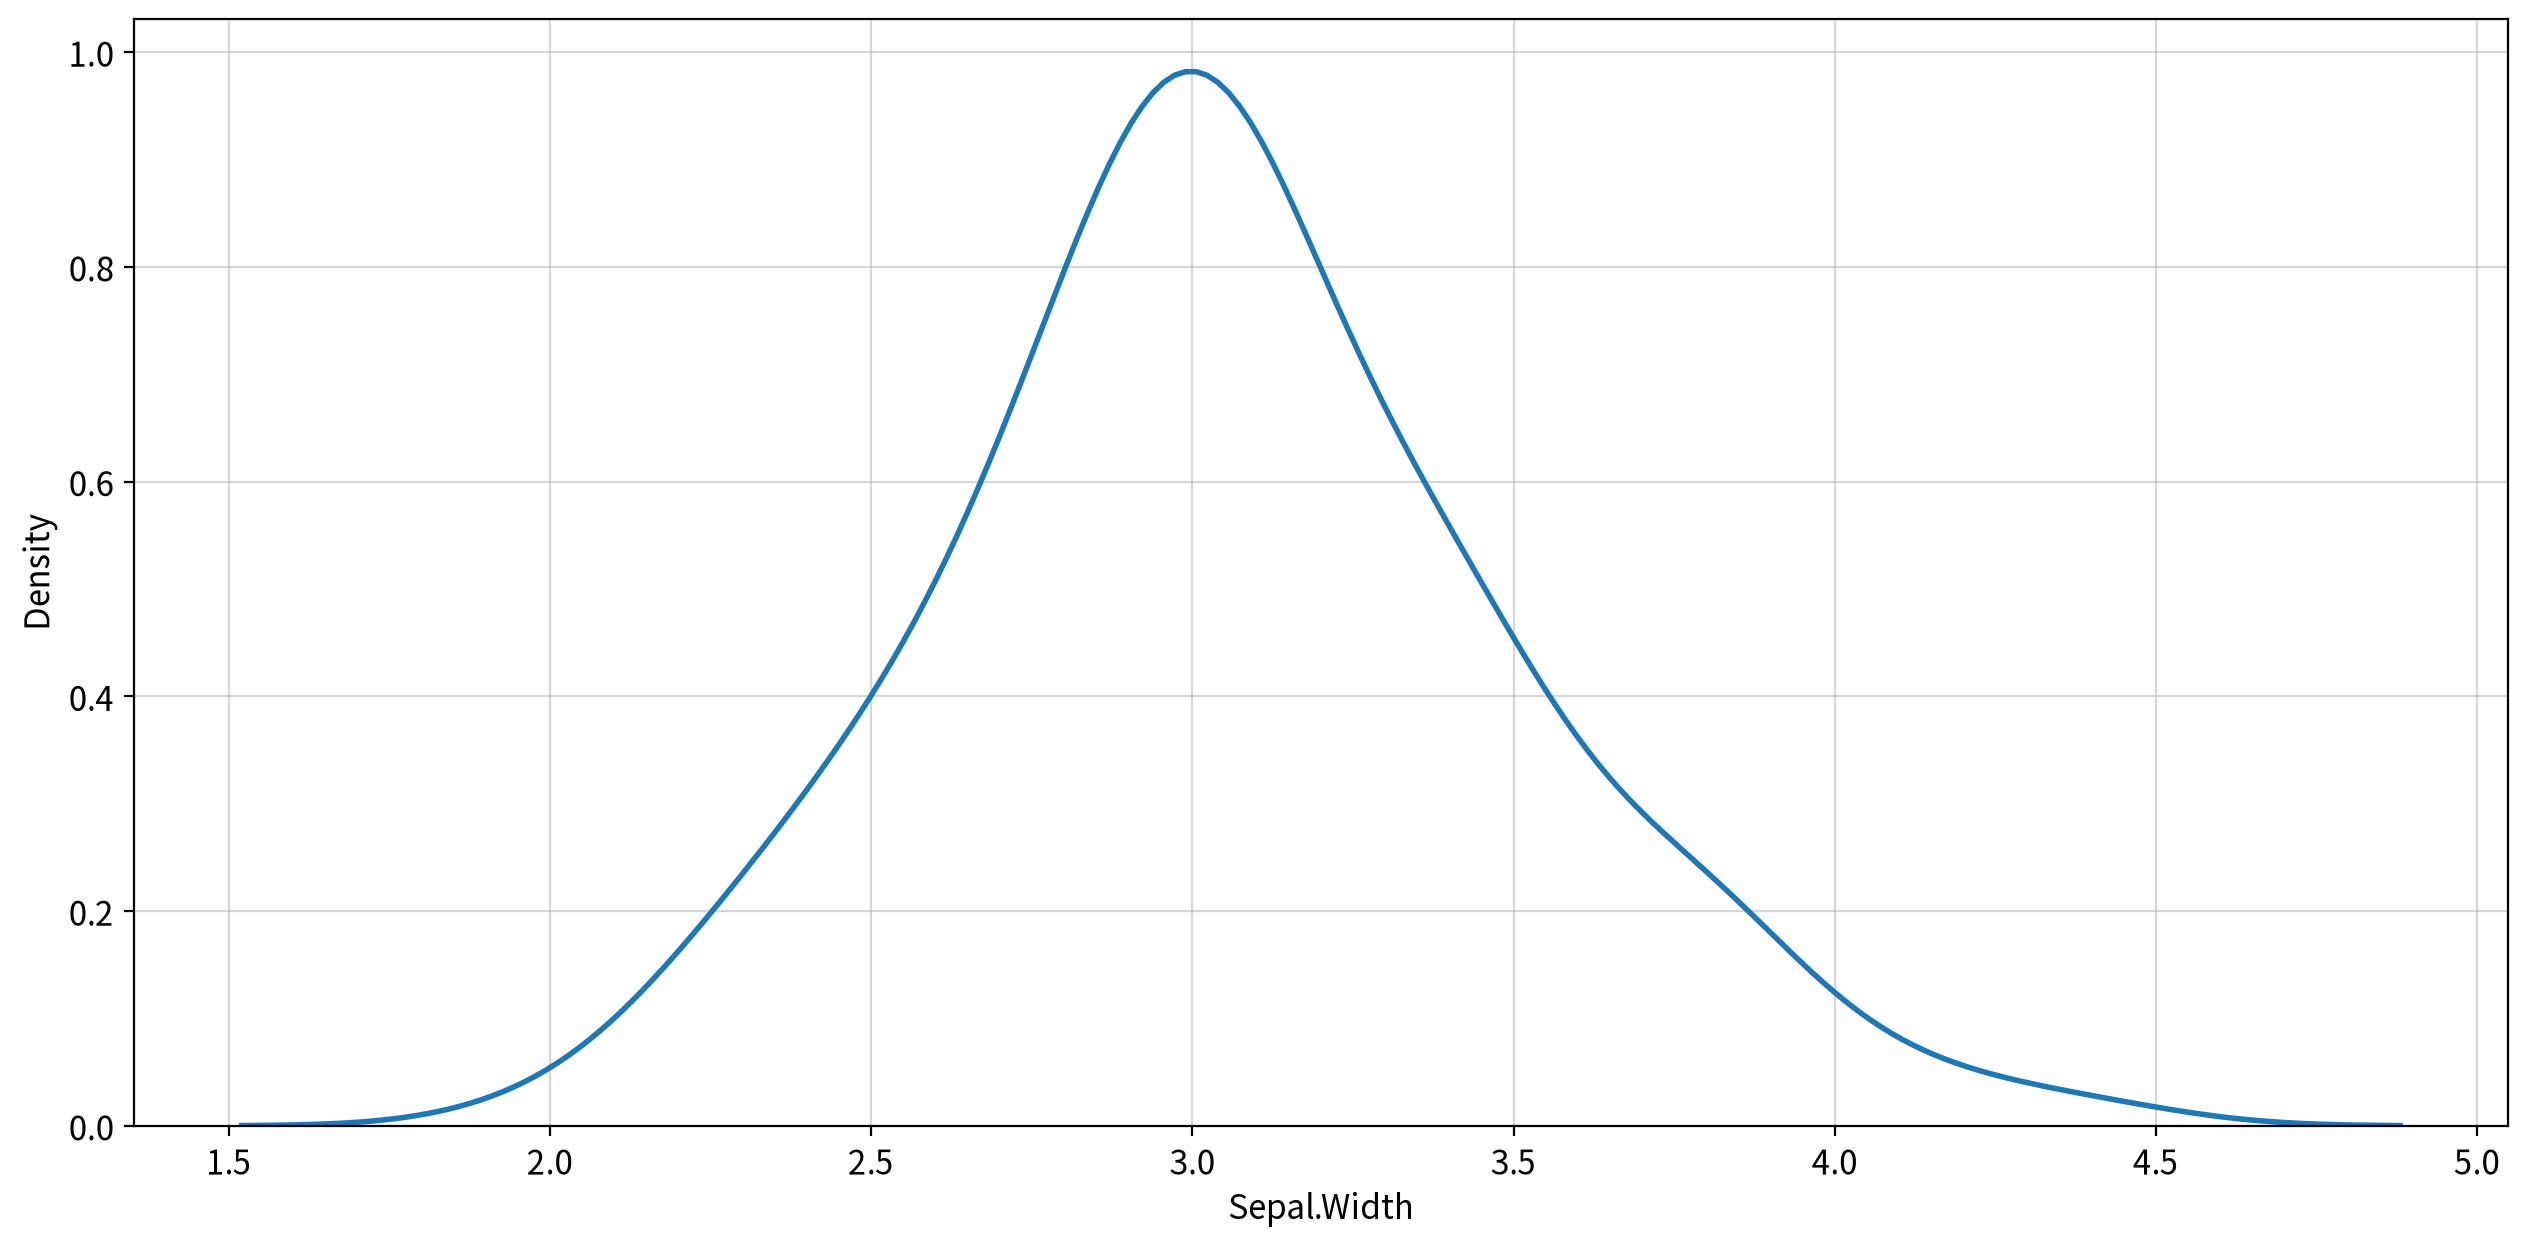

In [9]:
my_plot.kdeplot(data=origin, x="Sepal.Width")

### 2. 제목, 라벨, 평균선 표시 / 색상 채우기

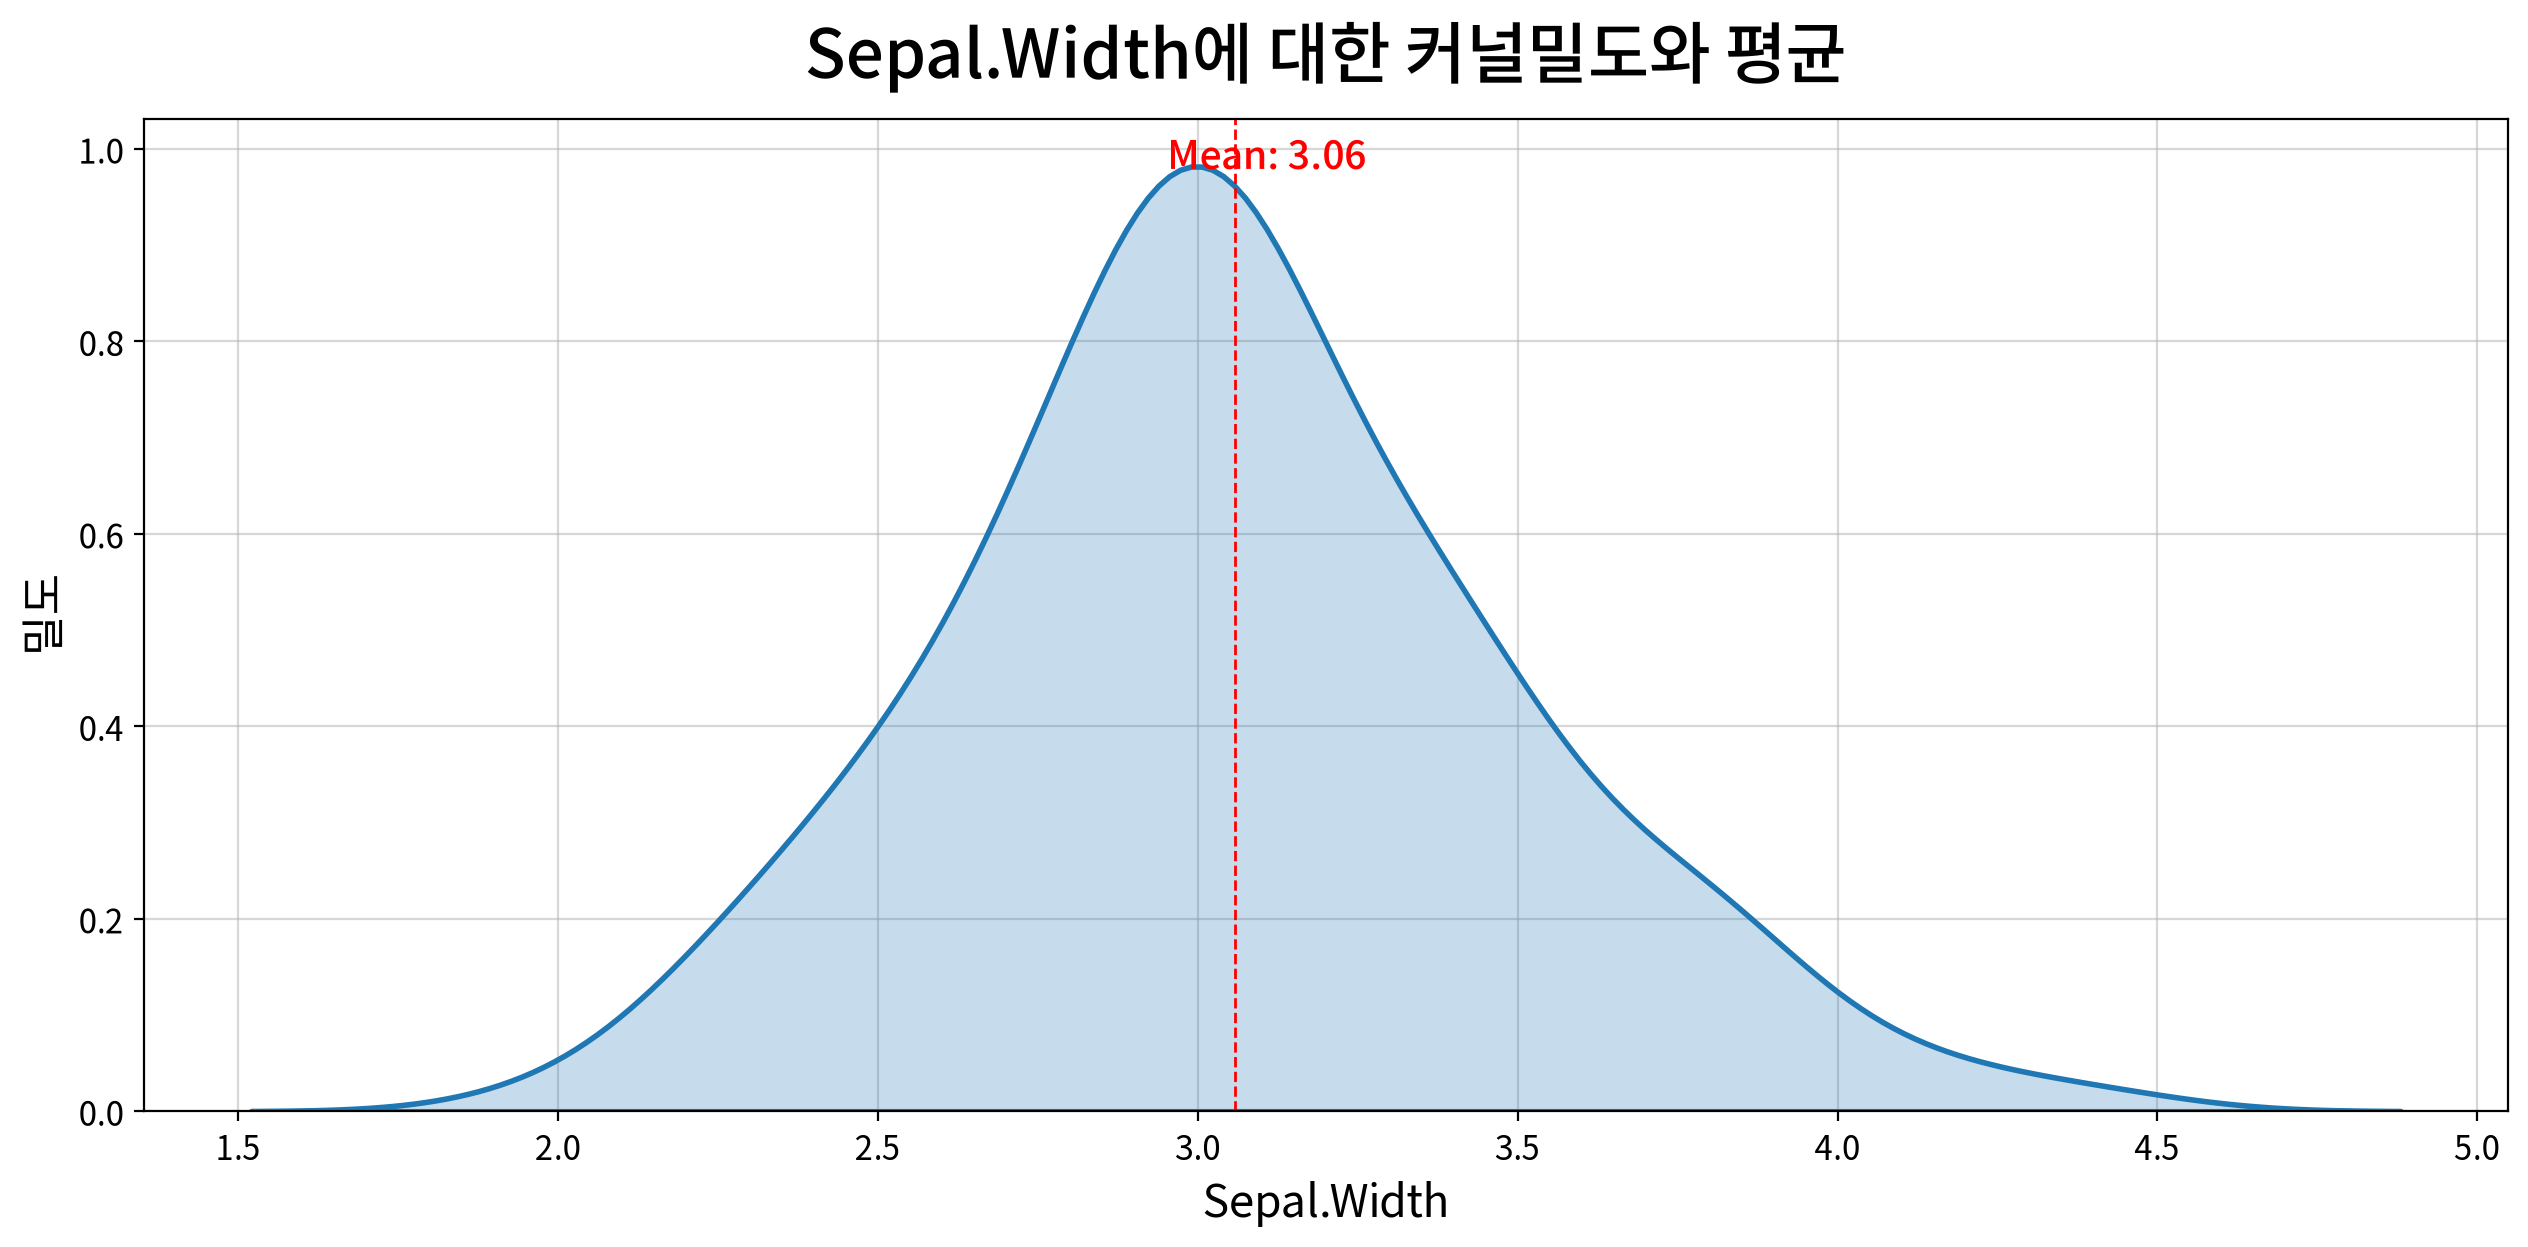

In [10]:
my_plot.kdeplot(title="Sepal.Width에 대한 커널밀도와 평균", 
                xlabel="Sepal.Width", ylabel="밀도", 
                data=origin, x="Sepal.Width", meanline=True, fill=True)

### 3. 범주에 따른 구분

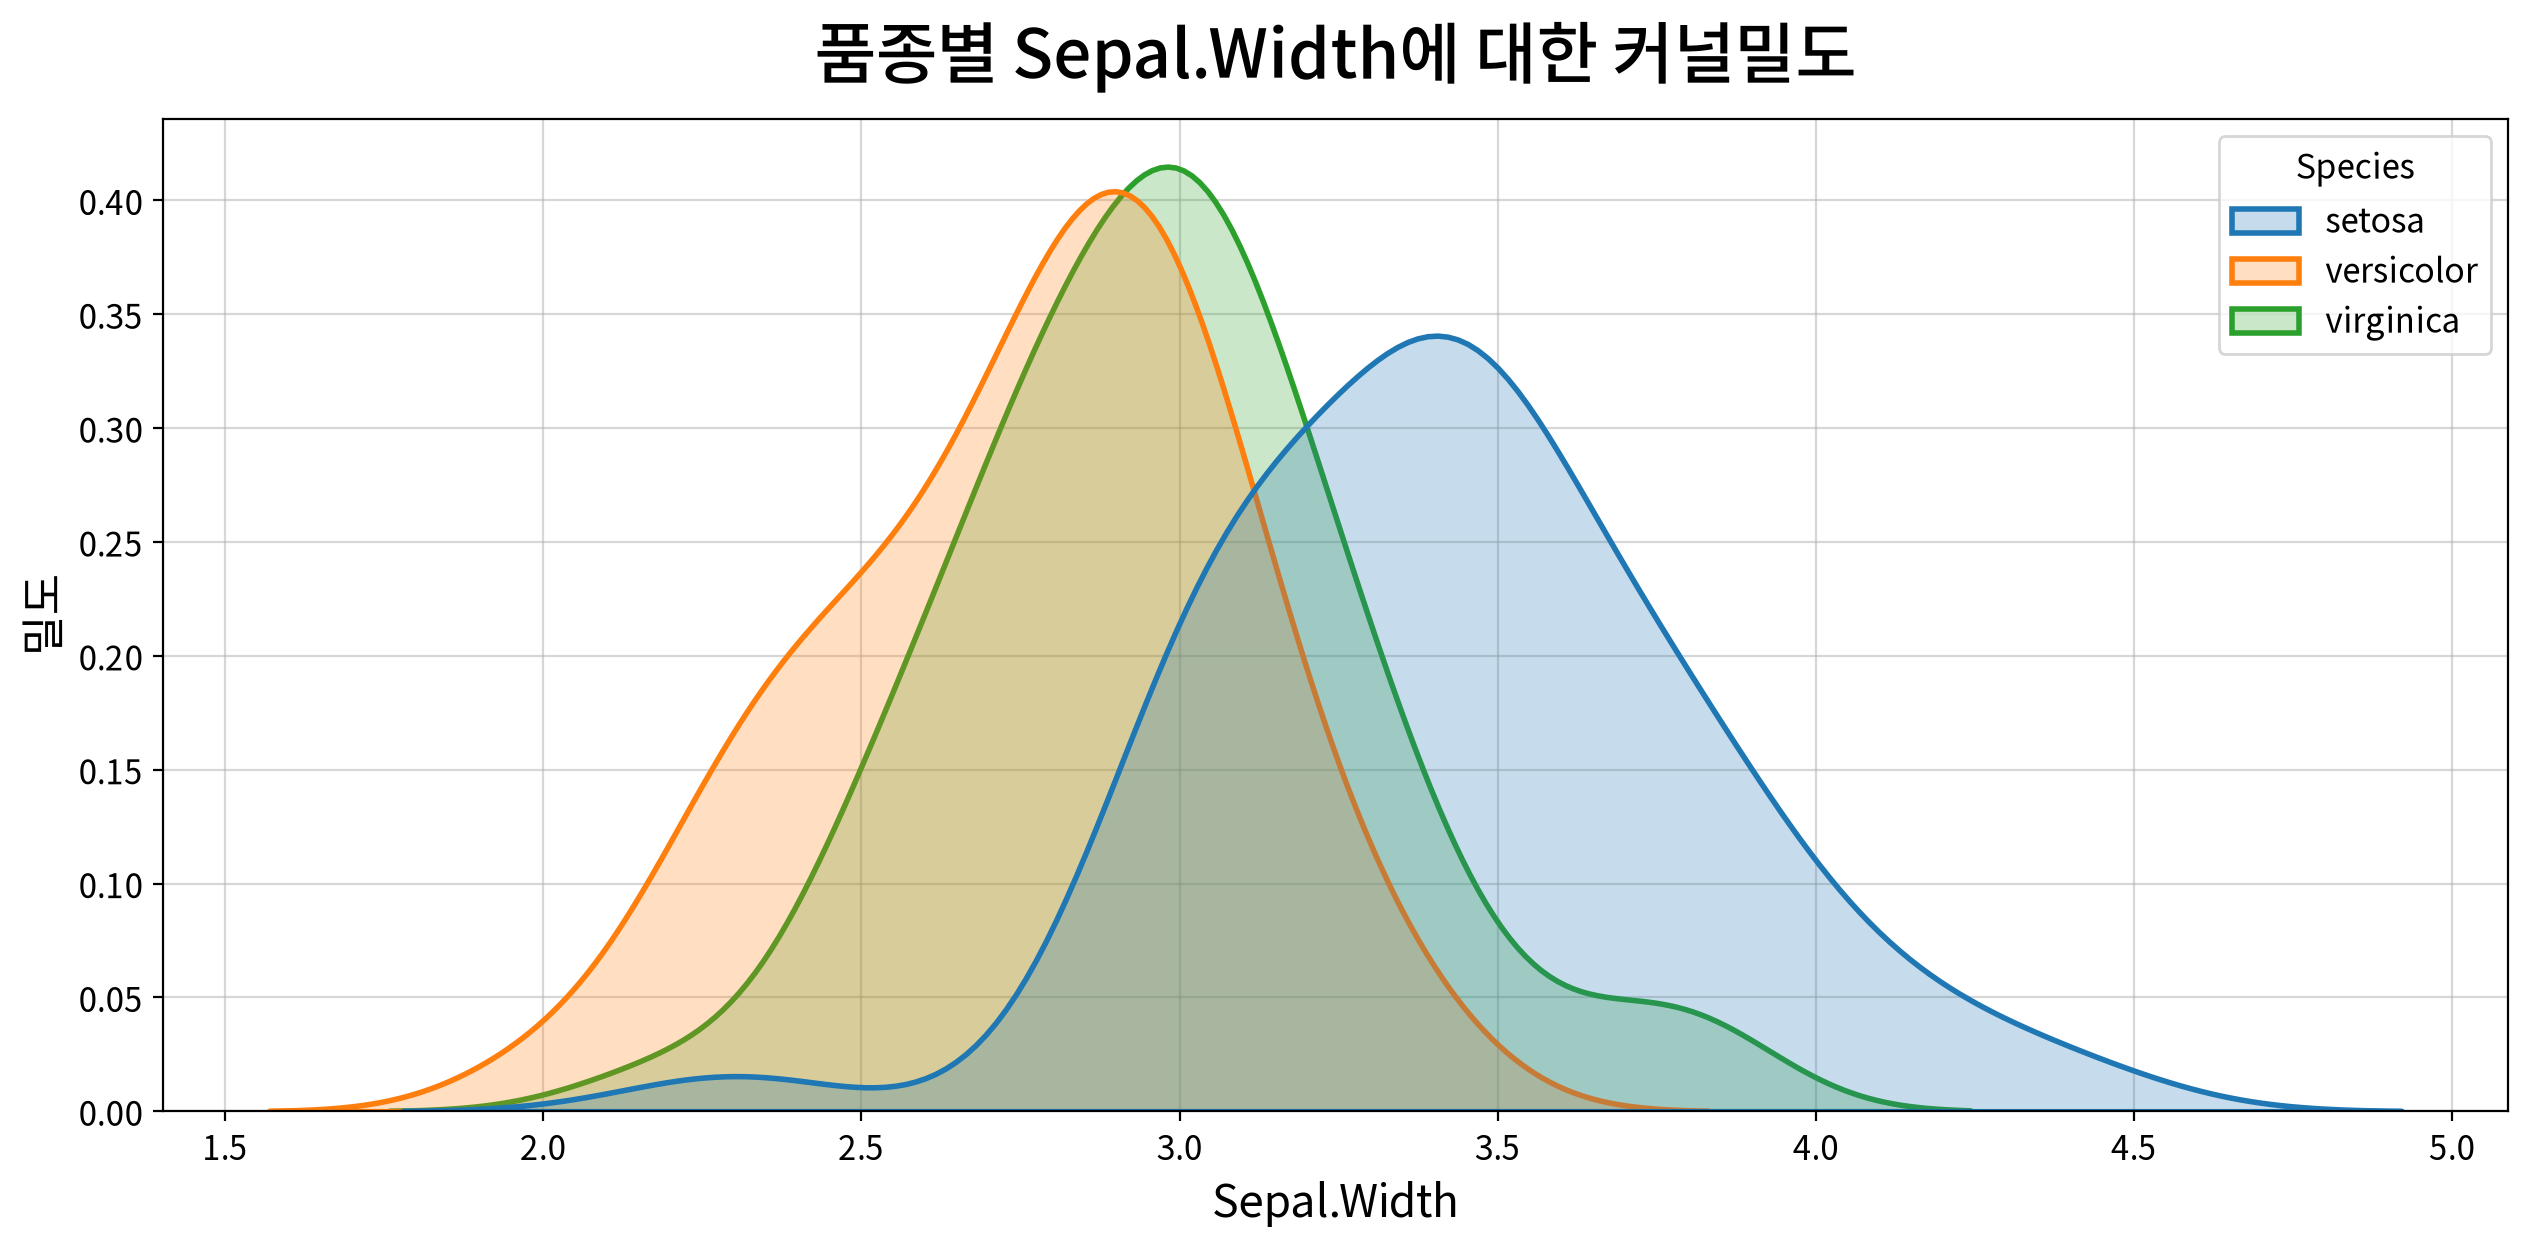

In [11]:
my_plot.kdeplot(title="품종별 Sepal.Width에 대한 커널밀도", 
                xlabel="Sepal.Width", ylabel="밀도", 
                data=origin, x="Sepal.Width", hue='Species', fill=True)

### 4. 범주에 따른 구분 + 평균선

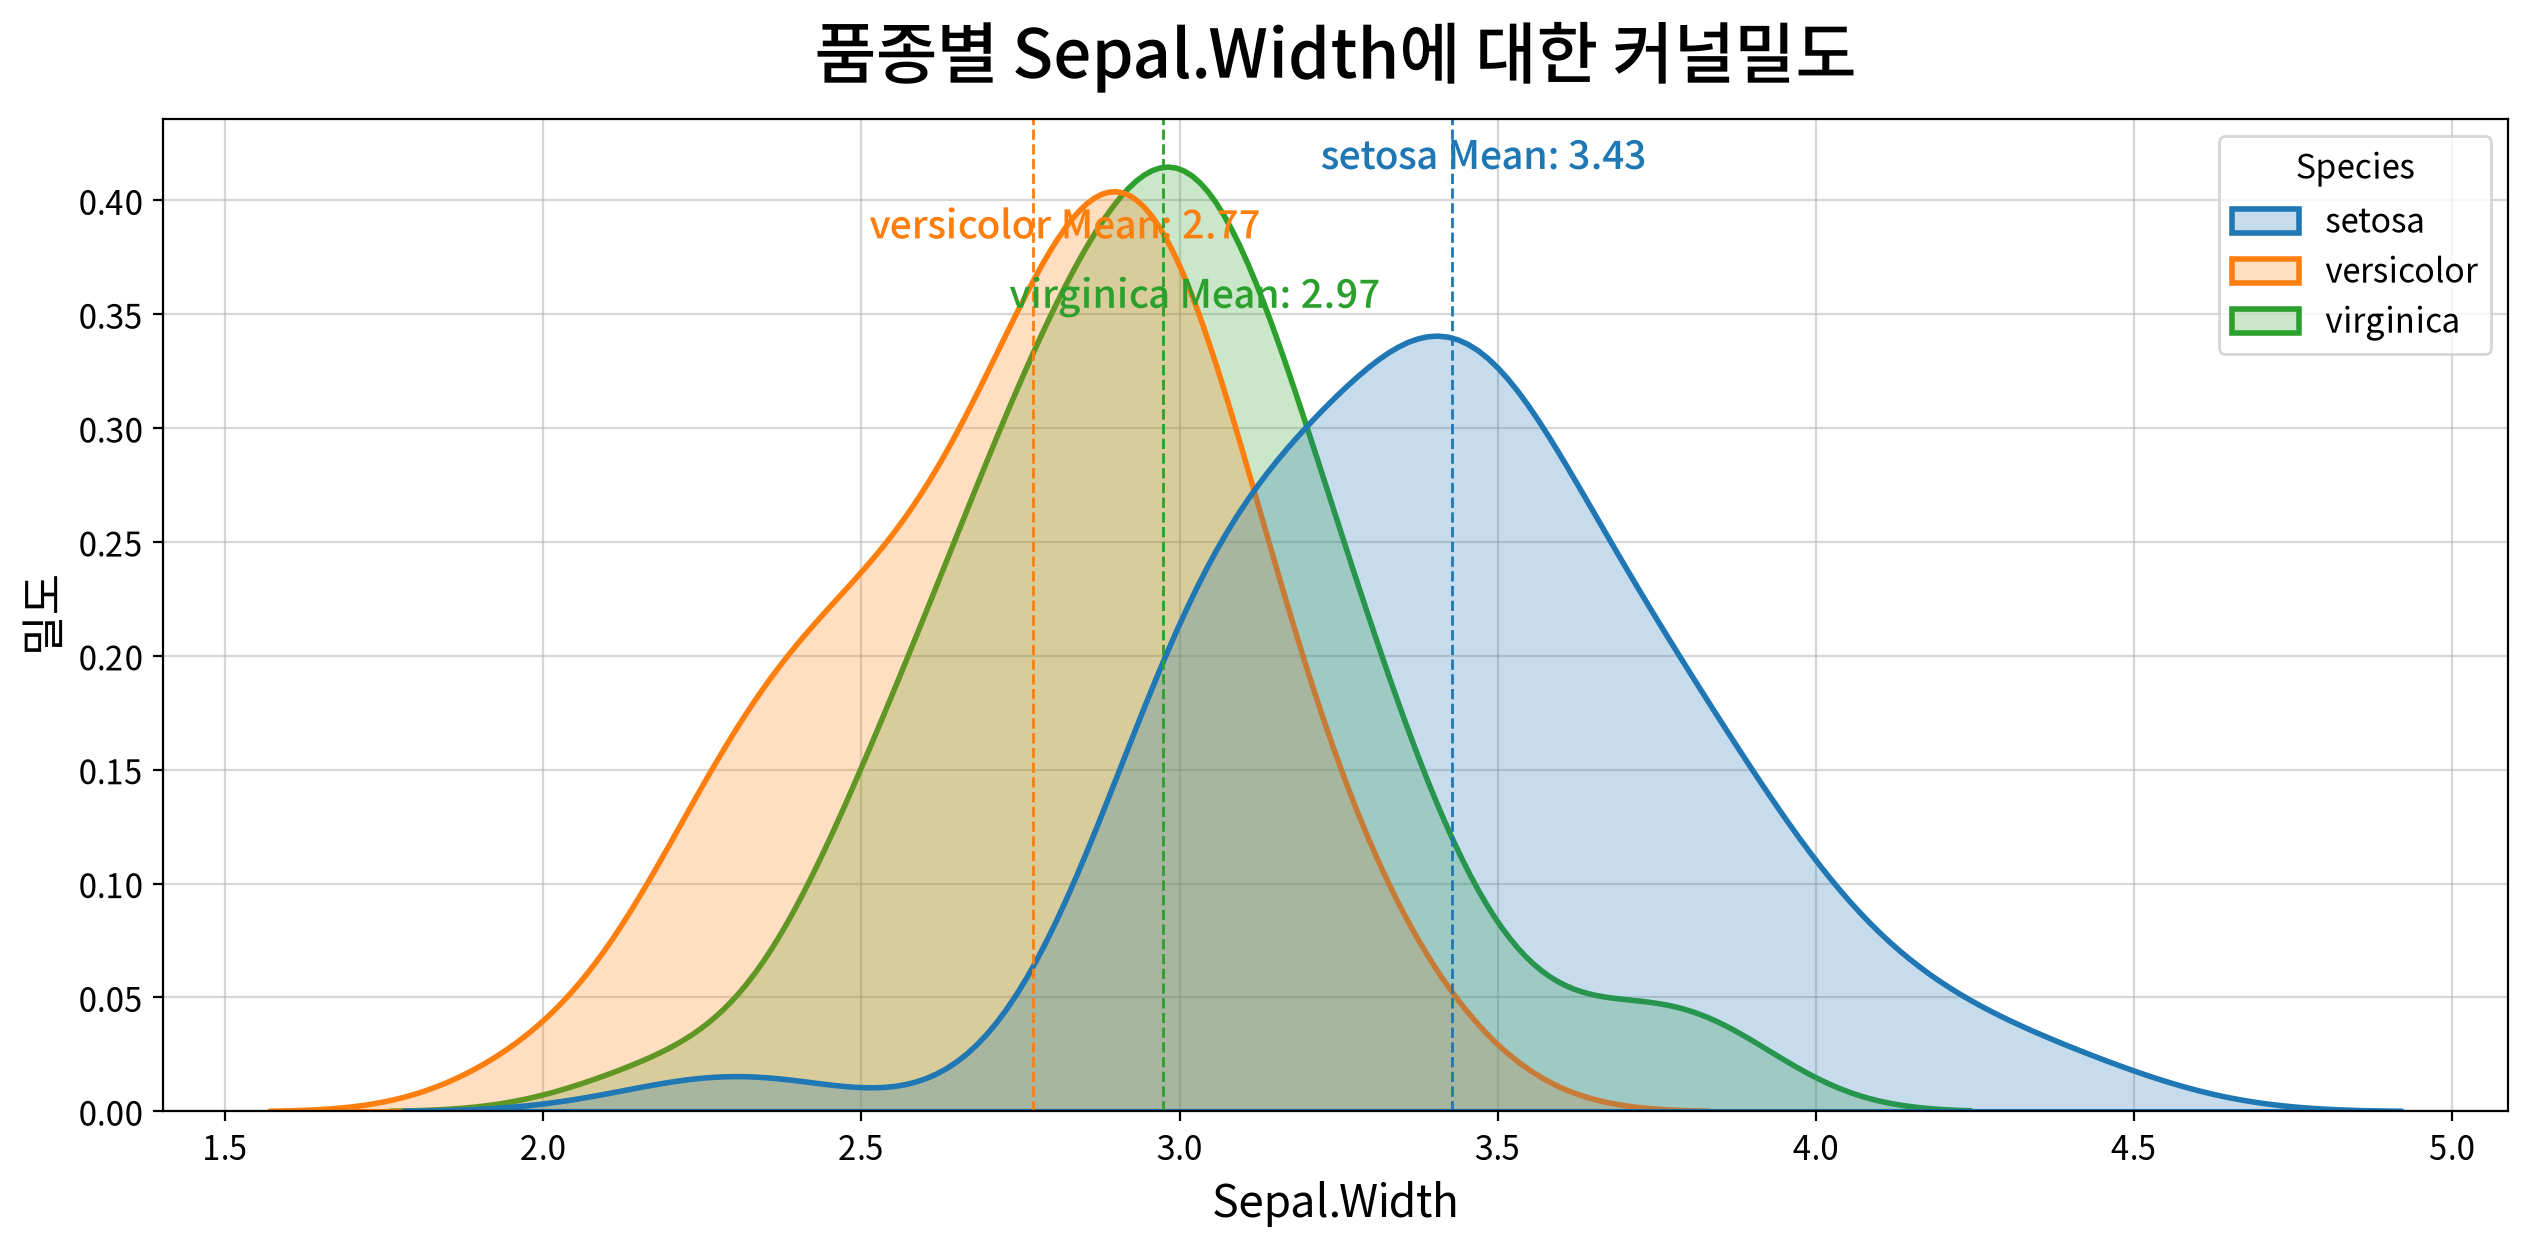

In [12]:
my_plot.kdeplot(title="품종별 Sepal.Width에 대한 커널밀도", 
                xlabel="Sepal.Width", ylabel="밀도", 
                data=origin, x="Sepal.Width", hue='Species', fill=True, meanline=True)